**Imports**

In [1]:
import pandas as pd
import tensorflow as tf
import numpy as np
from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import regularizers
from sklearn.model_selection import train_test_split
import sys
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix

**Deliverable 1: Data Loading and Preprocessing**

In [2]:
#load csv file (step 1.1)
train_df = pd.read_csv("sign_mnist_train.csv")
test_df = pd.read_csv("sign_mnist_test.csv")

print(train_df.shape, test_df.shape)
train_df.head()

(27455, 785) (7172, 785)


,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,3,107,118,127,134,139,143,146,150,153,...,207,207,207,207,206,206,206,204,203,202
1,6,155,157,156,156,156,157,156,158,158,...,69,149,128,87,94,163,175,103,135,149
2,2,187,188,188,187,187,186,187,188,187,...,202,201,200,199,198,199,198,195,194,195
3,2,211,211,212,212,211,210,211,210,210,...,235,234,233,231,230,226,225,222,229,163
4,13,164,167,170,172,176,179,180,184,185,...,92,105,105,108,133,163,157,163,164,179


In [3]:
# checking if my virtul env is set up correctly
# had to have python 3.11 as kernel bc tensor flow doesn't run on more updated versions of python
print(sys.executable)
print(sys.version)

/Users/fionac./nlpcv/tf-venv/bin/python
3.11.4 (v3.11.4:d2340ef257, Jun  6 2023, 19:15:51) [Clang 13.0.0 (clang-1300.0.29.30)]


In [4]:
num_classes = 25
# 24 classes (a-z excluding j&z)
input_shape = (28, 28, 1)
# 28 by 28 pixels, one channel bc grayscale image

#split train and test sets
y_train = train_df["label"].values
x_train = train_df.drop("label", axis=1).values

y_test = test_df["label"].values
x_test = test_df.drop("label", axis=1).values

#normalize values (scales to [0,1]) (step 1.2)
x_train = x_train.astype("float32") / 255
x_test = x_test.astype("float32") / 255

#reshape 
x_train = x_train.reshape(-1, 28, 28)
x_test = x_test.reshape(-1, 28, 28)

#ensuring images have correct shape (they do!)
x_train = np.expand_dims(x_train, -1)
x_test = np.expand_dims(x_test, -1)
print("x_train shape:", x_train.shape)
print(x_train.shape[0], "train samples")
print(x_test.shape[0], "test samples")


x_train shape: (27455, 28, 28, 1)
27455 train samples
7172 test samples


In [5]:
# creating validation split from train set (1.3)
x_train, x_val, y_train, y_val = train_test_split(x_train, y_train, test_size=0.2, random_state=42)
# stratify with y_train to make sure class distribution matches original dataset?
print("Train:", x_train.shape)
print("Val:", x_val.shape)
print("Test:", x_test.shape)

Train: (21964, 28, 28, 1)
Val: (5491, 28, 28, 1)
Test: (7172, 28, 28, 1)


**Deliverable 2: CNN Architectures**

In [6]:
#baseline cnn (step 2.1)
# changed second 32 to 64, because that pattern in past workshops worked better 
model = tf.keras.Sequential(
    [
        tf.keras.Input(shape=input_shape),
        layers.Conv2D(32, kernel_size=(3, 3), activation="relu", padding="same", kernel_regularizer=regularizers.l2(0.0001)),
        layers.Conv2D(32, kernel_size=(3, 3), activation="relu", padding="same", kernel_regularizer=regularizers.l2(0.0001)),
        layers.MaxPooling2D(pool_size=(2, 2)),
        layers.Conv2D(64, kernel_size=(3, 3), activation="relu", padding="same", kernel_regularizer=regularizers.l2(0.0001)),
        layers.Conv2D(64, kernel_size=(3, 3), activation="relu", padding="same", kernel_regularizer=regularizers.l2(0.0001)),
        layers.MaxPooling2D(pool_size=(2, 2)),
        layers.Flatten(),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation="softmax"),

    ]
)
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 28, 28, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 25)             │        78,425 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 143,417 (560.22 KB)

 Trainable params: 143,417 (560.22 KB)

 Non-trainable params: 0 (0.00 B)

In [7]:
from keras.optimizers import Adam

# Available optimizers
# SGD
# RMSprop
# Adam
# AdamW
# Adadelta
# Adagrad
# Adamax
# Adafactor
# Nadam
# Ftrl

batch_size = 64
epochs = 15

#Adm = Adam(lr=0.1)

model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    metrics=['accuracy']
)

In [8]:
history = model.fit(x_train, y_train, batch_size=128, epochs=25, validation_data=(x_val, y_val))
#baseline model with batch size of 128 and epochs of 100 took 21 mins to run

Epoch 1/25
172/172 ━━━━━━━━━━━━━━━━━━━━ 15s 81ms/step - accuracy: 0.5798 - loss: 1.3899 - val_accuracy: 0.9242 - val_loss: 0.2484
Epoch 2/25
172/172 ━━━━━━━━━━━━━━━━━━━━ 13s 78ms/step - accuracy: 0.9487 - loss: 0.1717 - val_accuracy: 0.9969 - val_loss: 0.0357
Epoch 3/25
172/172 ━━━━━━━━━━━━━━━━━━━━ 13s 77ms/step - accuracy: 0.9837 - loss: 0.0684 - val_accuracy: 0.9991 - val_loss: 0.0244
Epoch 4/25
172/172 ━━━━━━━━━━━━━━━━━━━━ 14s 79ms/step - accuracy: 0.9923 - loss: 0.0432 - val_accuracy: 0.9998 - val_loss: 0.0209
Epoch 5/25
172/172 ━━━━━━━━━━━━━━━━━━━━ 14s 81ms/step - accuracy: 0.9952 - loss: 0.0357 - val_accuracy: 1.0000 - val_loss: 0.0209
Epoch 6/25
172/172 ━━━━━━━━━━━━━━━━━━━━ 17s 100ms/step - accuracy: 0.9962 - loss: 0.0315 - val_accuracy: 0.9996 - val_loss: 0.0206
Epoch 7/25
172/172 ━━━━━━━━━━━━━━━━━━━━ 15s 90ms/step - accuracy: 0.9967 - loss: 0.0305 - val_accuracy: 1.0000 - val_loss: 0.0192
Epoch 8/25
172/172 ━━━━━━━━━━━━━━━━━━━━ 15s 86ms/step - accuracy: 0.9962 - loss: 0.0306 -

In [9]:
score = model.evaluate(x_test, y_test, verbose=0)
print("Test loss:", score[0])
print("Test accuracy:", score[1])
# baseline model had test loss of 0.93 and test acc of 0.84
# new model had test loss of 1.23 and test acc of 0.88
# adding drop out helped so much! 0.94 accuracy and test loss of 0.33 (0.3 dropout)
# even better with 0.5 dropout! 0.96 acc and test loss of 0.18
# 0.97 acc with adding 0.0001 l2 regularization

Test loss: 0.21010799705982208
Test accuracy: 0.9502230882644653


225/225 - 2s - 7ms/step - accuracy: 0.9502 - loss: 0.2101


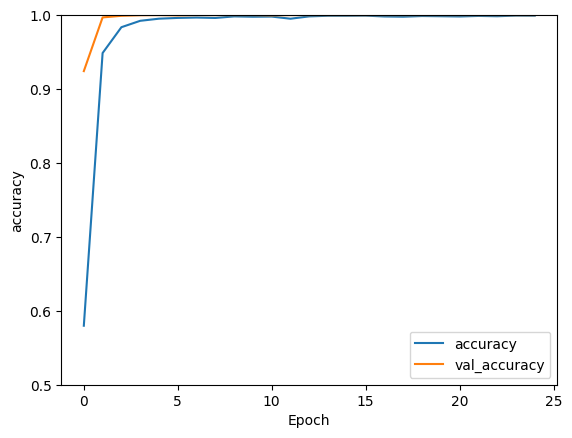

In [10]:
plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label = 'val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('accuracy')
plt.ylim([0.5, 1])
plt.legend(loc='lower right')

test_loss, test_acc = model.evaluate(x_test,  y_test, verbose=2)

**Deliverable 3: Training, Testing, and Evaluation**

In [11]:
y_pred_probs = model.predict(x_test)
y_pred_labels = np.argmax(y_pred_probs, axis=1)

225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step


In [12]:
cm = confusion_matrix(y_test, y_pred_labels)